# Disease Sample Scoring Pipeline

| Branch | 모델 | Score | 해석 |
|--------|------|-------|------|
| NBI (det≥10%) | GAMLSS NBI | z_nbi | 발현량 이상도 (calibrated) |
| Logistic (1-10%) | Logistic Regression | z_logistic | 검출 확률 이상도 |
| Rare (det<1%) | Poisson / Fixed | rare_score | 희소 발현 이상도 (uncalibrated) |

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')   # Modeling/ → pipeline 패키지 import
sys.path.insert(0, '..')  # ../config.py 참조
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config
from pipeline import data_prep, scoring, plots

In [2]:
# engine(NBI/Logistic) + rare_event_scorer 로드 (없으면 학습/구축, config 경로/파라미터)
engine, rare_scorer = scoring.load_engine()
print(f'  NBI genes : {len(engine.count_genes):,}   Logistic : {len(engine.logistic_genes):,}')

Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes
  NBI genes : 16,570   Logistic : 2,968


In [3]:
# disease/HC 분리 (raw Phenotype_Processed — study-split 미적용, scoring 원본 동일)
adata      = data_prep.load_adata()
is_hc      = (adata.obs['Phenotype_Processed'].astype(str) == 'Healthy Control').values
is_dis     = ~is_hc
Y          = data_prep.count_matrix(adata)
X_raw      = data_prep.bias_matrix(adata)
sample_ids = adata.obs_names.tolist()
gene_names = adata.var_names.tolist()
phenotypes = adata.obs['Phenotype_Processed'].astype(str).values
dis_idx    = np.where(is_dis)[0]
dis_names  = [sample_ids[i] for i in dis_idx]
dis_pheno  = phenotypes[dis_idx]
print(f'HC: {is_hc.sum()}  Disease: {is_dis.sum()}')
print(pd.Series(dis_pheno).value_counts().to_string())

HC: 693  Disease: 913
CAD_HF+               116
CAD_HF-               108
Tuberculosis          103
ME/CFS                 90
Pancreatitis           81
Pancreatic Cancer      74
Pre-eclampsia          62
Liver Cancer           48
Colorectal Cancer      41
Lung Cancer            33
Stomach Cancer         29
Esophagus Cancer       27
MM                     18
Other Cancer           18
HIV                    13
HIV + Tuberculosis     11
ICI-m                  11
ICI-treated Cancer     11
MGUS                    8
Pancreatic Cancer       6
Liver Cirrhosis         5


In [4]:
# 단일 샘플 스코어링 래퍼 (scoring.score_all 사용, 시각화용)
def score_sample(sample_idx):
    df = scoring.score_all(engine, rare_scorer, gene_names,
                           X_raw[[sample_idx]], Y[[sample_idx]],
                           [sample_ids[sample_idx]], [phenotypes[sample_idx]], min_abs_score=0.0)
    return df.drop(columns=['sample', 'phenotype'])

print('Scorer ready.')

Scorer ready.


In [5]:
# per-sample Manhattan 시각화 → pipeline.plots.plot_sample (z_flag = config.MODELING_PARAMS)
print('plots.plot_sample(df, sample_id, phenotype) 사용')

plots.plot_sample(df, sample_id, phenotype) 사용



Scoring Liver Cancer: SRR14506726
  Flagged genes: 252
              gene  score   score_type  raw_count
ENSG00000092377.15   10.0 rare_poisson       11.0
 ENSG00000142513.6   10.0 rare_poisson        9.0
 ENSG00000150750.9   10.0 rare_poisson       12.0
 ENSG00000172208.7   10.0 rare_poisson       10.0
ENSG00000185681.14   10.0 rare_poisson       36.0


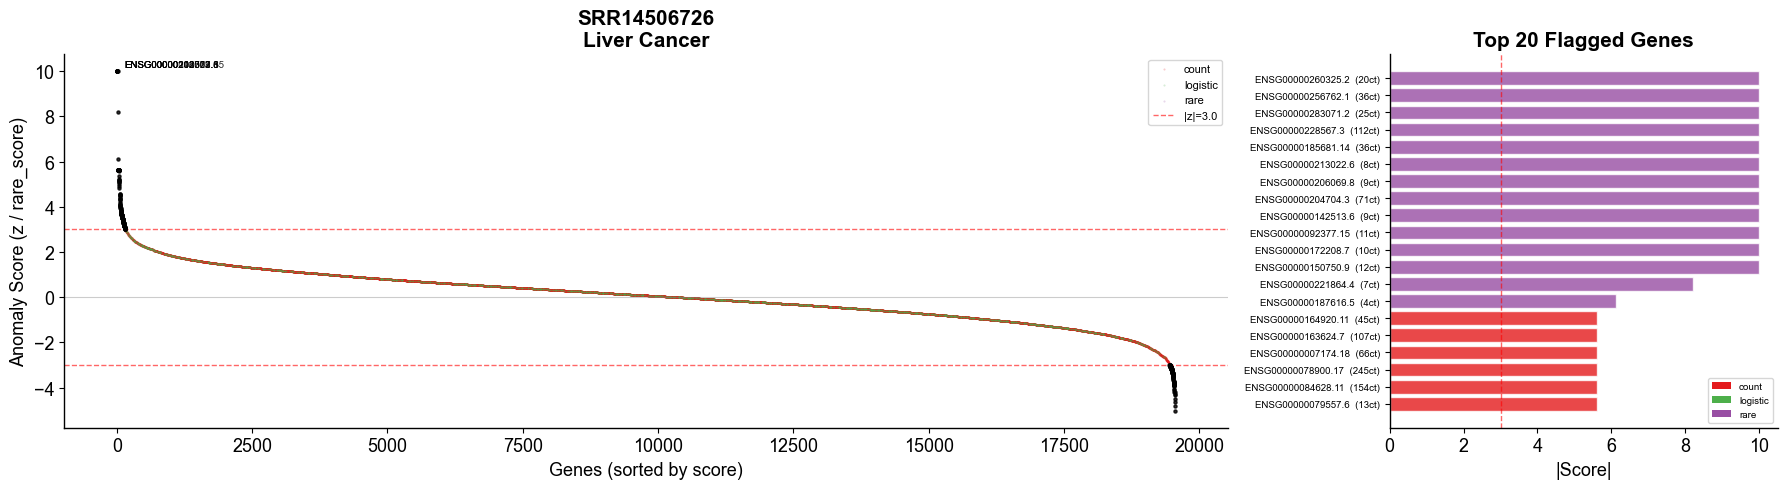


Scoring Pancreatic Cancer: SRR29803839
  Flagged genes: 45
              gene    score score_type  raw_count
ENSG00000204296.13 5.612001      nbi_z       58.0
 ENSG00000248329.7 5.612001      nbi_z        4.0
ENSG00000154274.16 5.057833      nbi_z       96.0
 ENSG00000284931.1 4.548844      nbi_z    70420.0
ENSG00000008323.17 3.926100      nbi_z       79.0


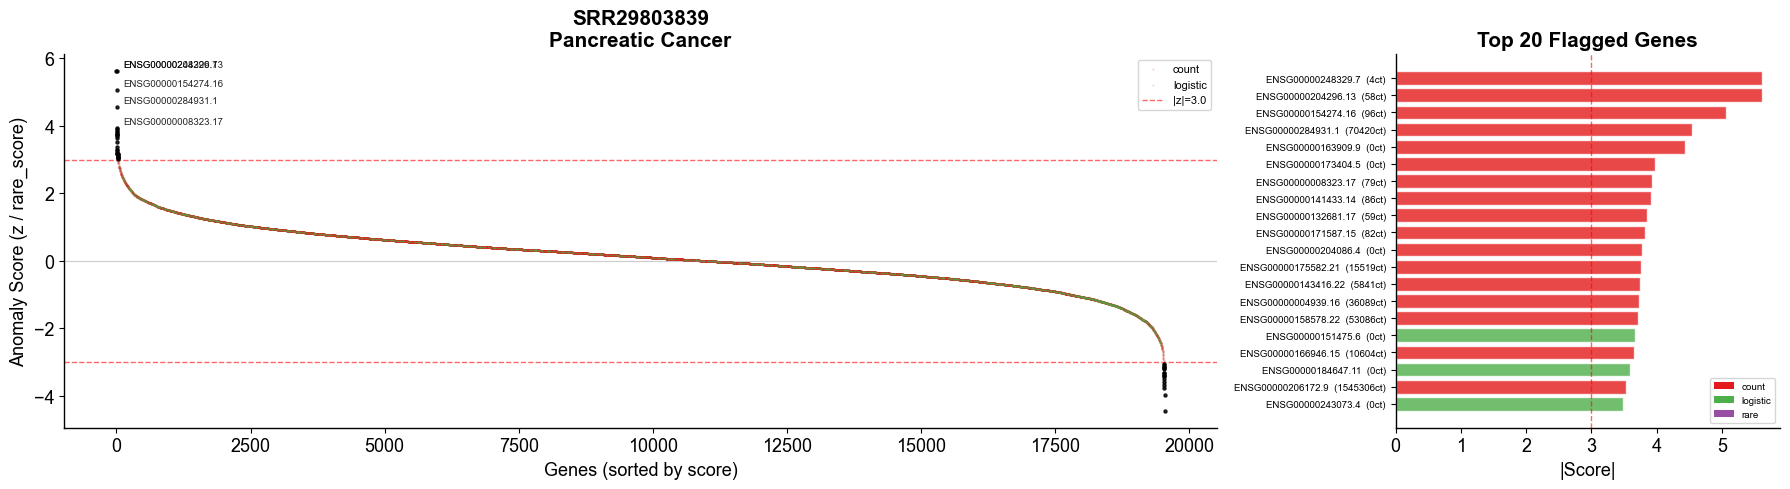


Scoring Tuberculosis: SRR28475979
  Flagged genes: 92
              gene    score   score_type  raw_count
ENSG00000142657.22 5.612001        nbi_z     1268.0
ENSG00000021355.14 5.501016        nbi_z     1218.0
ENSG00000143546.11 5.331437        nbi_z    16328.0
 ENSG00000171459.4 5.099282 rare_poisson        3.0
ENSG00000100504.18 5.097613        nbi_z     1001.0


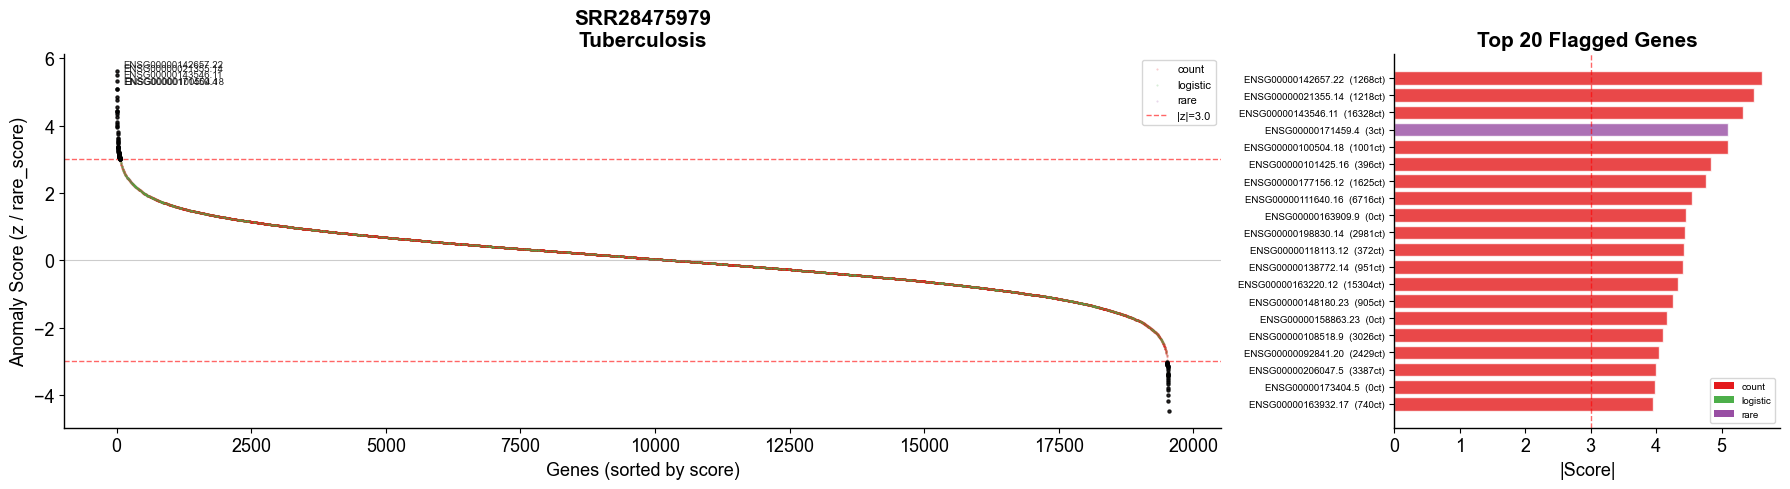

In [6]:
Z_FLAG = config.MODELING_PARAMS['z_flag']
for pheno in ['Liver Cancer', 'Pancreatic Cancer', 'Tuberculosis']:
    mask = (phenotypes == pheno) & is_dis
    if not mask.any():
        print(f'{pheno}: 샘플 없음'); continue
    idx = np.where(mask)[0][1]
    sid = sample_ids[idx]
    print(f'\nScoring {pheno}: {sid}')
    df = score_sample(idx)
    flagged = df[df['score'].abs() >= Z_FLAG]
    print(f'  Flagged genes: {len(flagged)}')
    print(flagged.nlargest(5, 'score')[['gene', 'score', 'score_type', 'raw_count']].to_string(index=False))
    fig = plots.plot_sample(df, sid, pheno)
    fig.savefig(config.CV_FIG_DIR / f'score_{pheno.replace(" ", "_")}.png', bbox_inches='tight', dpi=150)
    plt.show()

In [7]:
# 전체 disease Z matrix → Z_disease/sample/gene .npy + |z|>=z_flag long parquet
X_dis = X_raw[dis_idx]
Y_dis = Y[dis_idx]
Z_full, flagged = scoring.score_full(engine, rare_scorer, gene_names,
                                     X_dis, Y_dis, dis_names, dis_pheno)
print(f'Z matrix: {Z_full.shape}   flagged rows: {len(flagged):,}')

Z matrix: (913, 20097)  (11.5s)
Z matrix: (913, 20097)   flagged rows: 280,301
